In [4]:
# 生成数据
import matplotlib.pyplot as plt
import json
import numpy as np

from rplan.floorplan import Floorplan
from rplan.align import align_fp_gt
from rplan.decorate import get_dw
from rplan.measure import compute_tf
from rplan.plot import get_figure,get_axes,plot_category,plot_boundary,plot_graph,plot_fp,plot_tf
import os
import tqdm

RPLAN_DIR = './data'
for i in range(8):
    ret = dict()
    for _ in tqdm.tqdm(range(i * 10000, i * 10000 + 10000)):
        file_path = f'{RPLAN_DIR}/{_}.png'
        fp = Floorplan(file_path)
        img = fp.image
        data = fp.to_dict()
        boxes_aligned, order, room_boundaries ,edges= align_fp_gt(data['boundary'],data['boxes'],data['types'],data['edges'])
        data['boxes_aligned'] = boxes_aligned
        data['order'] = order
        data['room_boundaries'] = room_boundaries


        doors,windows = get_dw(data)
        # 'doors': doors.tolist(), 
        # 'windows': windows.tolist(), 
        ret[_] = {
                'boundary': data['boundary'],
                'box': data['boxes_aligned'][order],
                'type': data['types'][order],
                'edges': data['edges'],
                'room_boundaries': room_boundaries
                }

    import pickle

    # 假设 ret 是您要保存的数据对象
    with open(f'data{i}.pkl', 'wb') as f:  # 以二进制模式打开文件
        pickle.dump(ret, f)  # 使用 pickle 保存数据


100%|██████████| 10000/10000 [11:10<00:00, 14.91it/s]


In [27]:
import pickle
# 加载数据
ret = {}
for i in range(8):
    with open(f'data{i}.pkl', 'rb') as f:  # 以二进制读取模式打开文件
        ret = ret | pickle.load(f)  # 从文件中加载数据

In [28]:
# 切分函数
def get_line(room_boundaries):
    ret = []
    for i in room_boundaries:
        for j in i:
            ret.append(j)
    ret = np.array(ret)
    x = ret.T[0]
    y = ret.T[1]
    set_x = set(x)
    set_y = set(y)
    line = []
    for _ in set_x:
        index = np.where(x == _)
        first = True
        last_point = []
        this_point = []
        for i, j in zip(x[index], np.sort(y[index])):
            if first:
                this_point = [i, j]
                first = False
                continue
            else:
                last_point = this_point
                this_point = [i, j]
                if last_point != this_point:

                    line.append([this_point, last_point])
    for _ in set_y:
        index = np.where(y == _)
        first = True
        last_point = []
        this_point = []
        for i, j in zip(np.sort(x[index]), y[index]):
            if first:
                this_point = [i, j]
                first = False
                continue
            else:
                last_point = this_point
                this_point = [i, j]
                if last_point != this_point:

                    line.append([this_point, last_point])

    return np.array(line)

from shapely import geometry
def split_line(line, boundary):
    poly_boundary = geometry.Polygon(boundary)
    boundary_line = []
    room_boundaries_line = []

    for _ in line:
        # 创建点对象
        line_ = geometry.LineString([(_.T[0][0], _.T[1][0]), (_.T[0][1], _.T[1][1])])
        
        is_inside = poly_boundary.exterior.contains(line_)#.touches(line_) #touches(line_)
        if is_inside:
            boundary_line.append([_[0], _[1]])
        else:
            if poly_boundary.contains(line_):
                room_boundaries_line.append([_[0], _[1]])
    return np.array(boundary_line), np.array(room_boundaries_line)


def normalize(line, boundary):
    w_max, w_min, h_max, h_min = boundary[:, 0].max(), boundary[:, 0].min(),boundary[:, 1].max(), boundary[:, 1].min()
    wh_max = max(w_max, h_max)
    wh_min = min(w_min, h_min)

    return (line - wh_min) / (wh_max - wh_min)

(28, 2, 2) (15, 2, 2) (13, 2, 2)


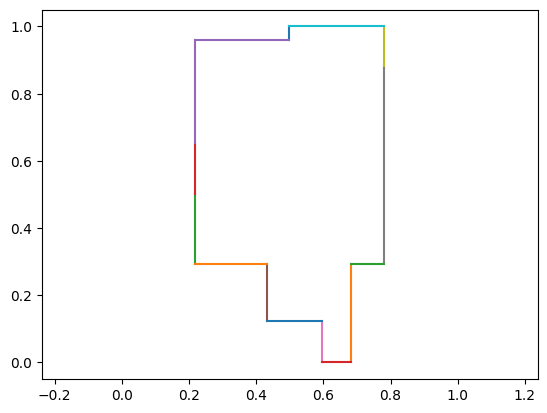

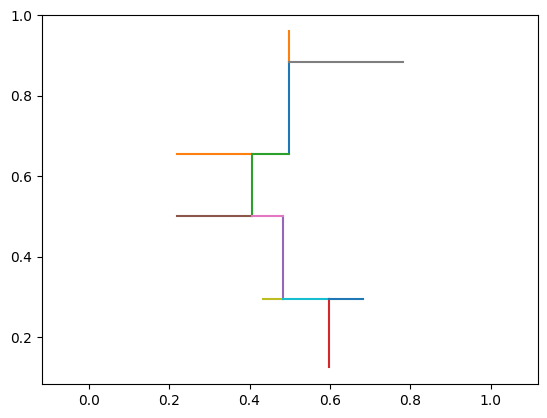

In [29]:
import pylab as plt
import numpy as np
# 示例函数
lines = get_line(ret[0]['room_boundaries'])
boundary_line, room_boundaries_line = split_line(lines, ret[0]['boundary'][:, :2])
boundary_line = normalize(boundary_line, ret[0]['boundary'])
room_boundaries_line = normalize(room_boundaries_line, ret[0]['boundary'])
print(lines.shape, boundary_line.shape, room_boundaries_line.shape)
t = 0
for _ in boundary_line:
    if _.T[0].min() ==  _.T[0].max():
        y = [_.T[1].min() + t , _.T[1].max() - t]
        x = [_.T[0].min(), _.T[0].max()]
    else:
        x = [_.T[0].min() + t, _.T[0].max() - t]
        y = [_.T[1].min(), _.T[1].max()]
    plt.plot(x, y)
plt.axis('equal')
plt.show()
for _ in room_boundaries_line:
    if _.T[0].min() ==  _.T[0].max():
        y = [_.T[1].min() + t , _.T[1].max() - t]
        x = [_.T[0].min(), _.T[0].max()]
    else:
        x = [_.T[0].min() + t, _.T[0].max() - t]
        y = [_.T[1].min(), _.T[1].max()]
    plt.plot(x, y)
plt.axis('equal')
plt.show()

In [30]:
# 生成预备数据
ret_param = []
ret_seq_mask = []
ret_ignore_mask = []
def quantize_to_6bit(normalized_data):
    # 将数据量化到 [0, 63] 的整数范围
    quantized_data = np.round(normalized_data * 63).astype(np.uint8)
    return quantized_data

for i in list(ret.keys()):
    try:
        param = np.zeros((80, 4))
        lines = get_line(ret[i]['room_boundaries'])
        boundary_line, room_boundaries_line = split_line(lines, ret[i]['boundary'][:, :2])

        boundary_line = normalize(boundary_line, ret[i]['boundary'])
        room_boundaries_line = normalize(room_boundaries_line, ret[i]['boundary'])

        boundary_line_shape = boundary_line.shape[0]
        room_boundaries_line_shape = room_boundaries_line.shape[0]
        param[:boundary_line_shape, :] = boundary_line.reshape(boundary_line_shape, -1)
        param[boundary_line_shape:boundary_line_shape + room_boundaries_line_shape, :] = room_boundaries_line.reshape(room_boundaries_line_shape, -1)
        param = quantize_to_6bit(param)
        seq_mask = np.full((80), True, dtype=bool)
        seq_mask[:lines.shape[0]] = False

        ignore_mask = np.full((80, 4), False, dtype=bool)
        ignore_mask[boundary_line_shape:boundary_line_shape + room_boundaries_line_shape, :] = True
        
        # ignore_mask = np.concatenate(
        #     (np.full((boundary_line_shape, 4), False, dtype=bool),
        #     np.full((room_boundaries_line_shape, 4), True, dtype=bool),
        #     np.full((param.shape[0] - lines.shape[0], 4), False, dtype=bool),
        #     )
        # )
        
        ret_param.append(param)
        ret_seq_mask.append(seq_mask)
        ret_ignore_mask.append(ignore_mask)
    except:
        print(i)
    #print(lines.flatten().shape)

457
3277
6191
6459
6706
6757
8388
8624
12344
12355
15986
17061
18328
18603
21570
22241
23082
23336
23408
24698
25494
26029
26589
26931
28056
28212
28382
28828
29325
29456
29489
29688
30016
30450
33271
33396
34258
34676
36074
36079
36535
37117
37284
39135
41241
41413
41421
41442
42980
43424
43688
43783
43892
44926
56214
56441
58978
60536
63827
64411
65527
65556
65658
65788
66863
68221
68915
68964
69460
69643
69921
71447
72768
73232
74046
74106
75813
76864
79097


In [31]:
# 保存数据
param = np.stack(ret_param, axis=0)
seq_mask = np.stack(ret_seq_mask, axis=0)
ignore_mask = np.stack(ret_ignore_mask, axis = 0)
# rows_to_delete = [1, 3]  # 删除第 1 和第 3 行
# cols_to_delete = [0, 2]   # 删除第 0 和第 2 列

# # 删除行
# array = np.delete(array, rows_to_delete, axis=0)
train_param = param[:int(param.shape[0]* 0.7)]#, np.arange(89 * 256, 90 * 256), axis = 0)
train_seq_mask = seq_mask[:int(seq_mask.shape[0] * 0.7)]#, np.arange(89 * 256, 90 * 256), axis = 0)
train_ignore_mask = ignore_mask[:int(ignore_mask.shape[0] * 0.7)]#, np.arange(89 * 256, 90 * 256), axis = 0)

val_param = param[int(param.shape[0]* 0.7):int(param.shape[0]* 0.9)]
val_seq_mask = seq_mask[int(seq_mask.shape[0] * 0.7):int(param.shape[0]* 0.9)]
val_ignore_mask = ignore_mask[int(ignore_mask.shape[0] * 0.7):int(param.shape[0]* 0.9)]

test_param = param[int(param.shape[0]* 0.9):]
test_seq_mask = seq_mask[int(seq_mask.shape[0] * 0.9):]
test_ignore_mask = ignore_mask[int(ignore_mask.shape[0] * 0.9):]

# 使用 pickle 保存 numpy 数组到文件
with open('train.pkl', 'wb') as f:
    pickle.dump({'param': train_param, 'seq_mask': train_seq_mask, 'ignore_mask': train_ignore_mask}, f)

# 使用 pickle 保存 numpy 数组到文件
with open('test.pkl', 'wb') as f:
    pickle.dump({'param': test_param, 'seq_mask': test_seq_mask, 'ignore_mask': test_ignore_mask}, f)

# 使用 pickle 保存 numpy 数组到文件
with open('val.pkl', 'wb') as f:
    pickle.dump({'param': val_param, 'seq_mask': val_seq_mask, 'ignore_mask': val_ignore_mask}, f)


In [13]:

with open('error.pkl', 'wb') as f:
    pickle.dump({'param': param[89 * 256 : 90 * 256], 'seq_mask': seq_mask[89 * 256 : 90 * 256], 'ignore_mask': ignore_mask[89 * 256 : 90 * 256]}, f)